<a href="https://colab.research.google.com/github/JosefinaMenta/Aprendizaje-Autom-tico-2026/blob/main/Clase%204/%20Ejercicio%201/%20Notebook/%20Ejercicio_1_clase_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Análisis del Índice de Felicidad Mundial (2019)**

La presente notebook corresponde al ejercicio 1 clase 4 del bloque de Aprendizaje Automático, donde presento un dataset extraído de kaggle que recopila información de 156 países para medir qué tan felices se perciben sus ciudadanos y entender qué factores explican esas diferencias globales.

**Objetivo**:
Construir un modelo de Regresión Lineal para predecir la felicidad (Score) a partir de estos indicadores.

In [5]:
import pandas as pd

df = pd.read_csv('2019.csv')

print("--- PRIMERAS 5 FILAS DEL DATASET ---")
df.head()

--- PRIMERAS 5 FILAS DEL DATASET ---


,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


In [6]:
# Ver información del dataset y valores faltantes
print("--- INFORMACIÓN GENERAL ---")
df.info()

print("\n--- RESUMEN ESTADÍSTICO ---")
df.describe()

--- INFORMACIÓN GENERAL ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Overall rank                  156 non-null    int64  
 1   Country or region             156 non-null    object 
 2   Score                         156 non-null    float64
 3   GDP per capita                156 non-null    float64
 4   Social support                156 non-null    float64
 5   Healthy life expectancy       156 non-null    float64
 6   Freedom to make life choices  156 non-null    float64
 7   Generosity                    156 non-null    float64
 8   Perceptions of corruption     156 non-null    float64
dtypes: float64(7), int64(1), object(1)
memory usage: 11.1+ KB

--- RESUMEN ESTADÍSTICO ---


,Overall rank,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
count,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000,156.000000
mean,78.500000,5.407096,0.905147,1.208814,0.725244,0.392571,0.184846,0.110603
std,45.177428,1.113120,0.398389,0.299191,0.242124,0.143289,0.095254,0.094538
min,1.000000,2.853000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,39.750000,4.544500,0.602750,1.055750,0.547750,0.308000,0.108750,0.047000
50%,78.500000,5.379500,0.960000,1.271500,0.789000,0.417000,0.177500,0.085500
75%,117.250000,6.184500,1.232500,1.452500,0.881750,0.507250,0.248250,0.141250
max,156.000000,7.769000,1.684000,1.624000,1.141000,0.631000,0.566000,0.453000


Se identifica la estructura:

* **Variable Objetivo ($Y$):**
  * Score: Puntuación numérica continua del nivel de felicidad de cada país (rango de ~2.8 a 7.7).

* **Variables Predictoras ($X$):**
  1. GDP per capita: Poder adquisitivo y bienestar económico general.
  2. Social support: Percepción de contar con apoyo familiar o de amigos ante un problema.
  3. Healthy life expectancy: Años promedio de vida con buena salud física.
  4. Freedom to make life choices: Grado de libertad percibido para tomar decisiones vitales.
  5. Generosity: Nivel de donaciones y solidaridad en la población.
  6. Perceptions of corruption: Nivel de confianza o corrupción percibida en el gobierno/empresas.

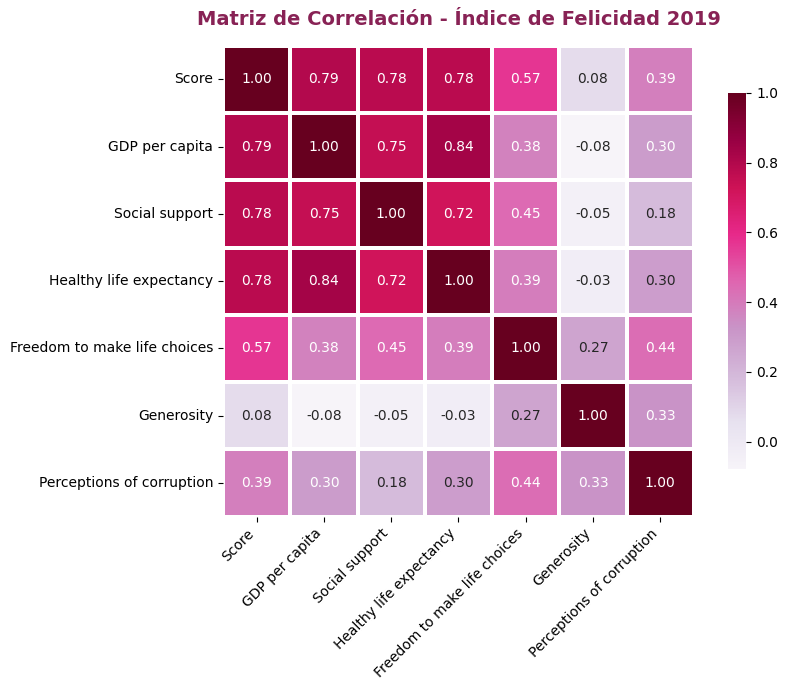

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

#seleccionar las columnas numéricas para la correlación
columnas_interes = [
    'Score',
    'GDP per capita',
    'Social support',
    'Healthy life expectancy',
    'Freedom to make life choices',
    'Generosity',
    'Perceptions of corruption'
]

#  tamaño y estilo del gráfico
plt.figure(figsize=(9, 7))

# mapa de calor con paleta rosa/morada ('PuRd' o 'RdPu')
sns.heatmap(
    df[columnas_interes].corr(),
    annot=True,
    fmt=".2f",
    cmap='PuRd',
    linewidths=1.5,
    linecolor='white',
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title('Matriz de Correlación - Índice de Felicidad 2019', fontsize=14, pad=15, color='#882255', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Selección de Variables

A partir del mapa de calor, se observa que **GDP per capita**, **Social support** y **Healthy life expectancy** son las variables con mayor correlación lineal con la felicidad ($r > 0.70$).

Por el contrario, variables como Generosity y Perceptions of corruption muestran una correlación débil ($r < 0.40$). Por lo tanto, se seleccionan las primeras tres como predictores ($X$) para priorizar las métricas con mayor fuerza explicativa y evitar introducir ruido al modelo.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    explained_variance_score,
    r2_score
)

# definir variables predictoras (X) y objetivo (y)
features = ['GDP per capita', 'Social support', 'Healthy life expectancy']
X = df[features]
y = df['Score']

# dvidir en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# entrenar Regresión Lineal
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)

# entrenar Regresión contraída
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)
y_pred_ridge = model_ridge.predict(X_test)

#  métricas
def mostrar_metricas(nombre, y_real, y_pred):
    print(f"=== {nombre.upper()} ===")
    print(f"Error absoluto medio:      {mean_absolute_error(y_real, y_pred):.4f}")
    print(f"Error cuadrático medio:     {mean_squared_error(y_real, y_pred):.4f}")
    print(f"Error absoluto mediana:   {median_absolute_error(y_real, y_pred):.4f}")
    print(f"Varianza explicada:        {explained_variance_score(y_real, y_pred):.4f}")
    print(f"Puntuación R2:             {r2_score(y_real, y_pred):.4f}\n")

mostrar_metricas("Regresión Lineal", y_test, y_pred_lr)
mostrar_metricas("Regresión Ridge (Alpha=1.0)", y_test, y_pred_ridge)

=== REGRESIÓN LINEAL ===
Error absoluto medio:      0.5440
Error cuadrático medio:     0.4637
Error absoluto mediana:   0.4639
Varianza explicada:        0.5572
Puntuación R2:             0.5545

=== REGRESIÓN RIDGE (ALPHA=1.0) ===
Error absoluto medio:      0.5441
Error cuadrático medio:     0.4562
Error absoluto mediana:   0.4583
Varianza explicada:        0.5643
Puntuación R2:             0.5617



El modelo explica el 55.5% de la variabilidad en la felicidad usando únicamente PIB, apoyo social y salud con un error promedio de 0.54 puntos. Si bien no es un porcentaje determinante para hacer predicciones exactas, es un resultado bastante sólido considerando que solo se usarn tres variables. La coincidencia casi exacta con la regresión Ridge confirma que el modelo es estable y no presenta sobreajuste. Para lograr un impacto mayor bastaría con incorporar en un futuro el resto de las variables del reporte.